# Intensity Transformations & Filtering Spatial Domain

## Thresholding

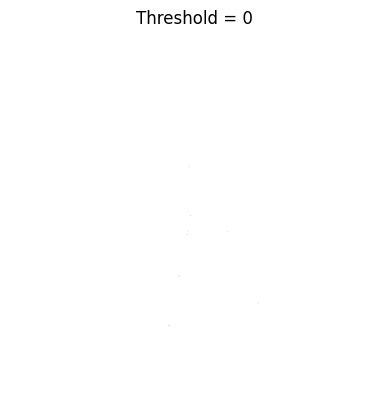

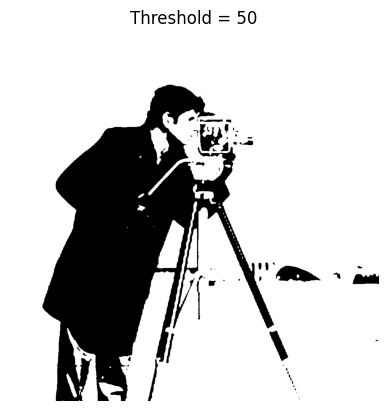

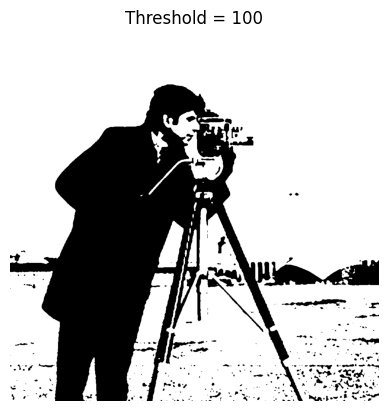

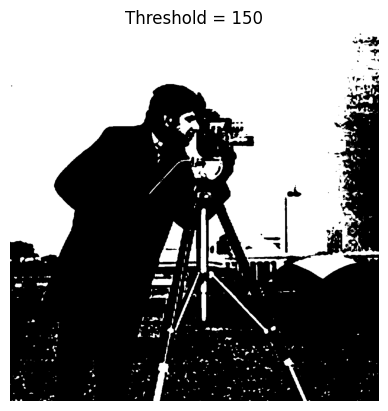

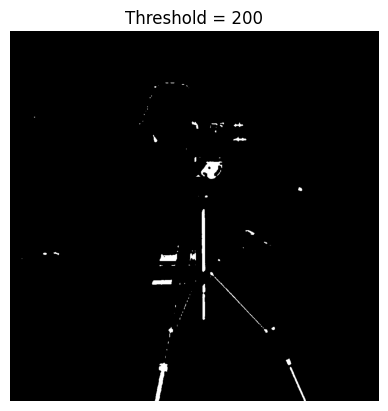

In [32]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    '''
    cv2.threshold(the img, threshold vlue, if it more than 255 then 255, transform type )
    cv2.THRESH_BINARY --> it means only white and black 
    cv2.threshold() returns threshold_value(because it is binary) and the new img
    '''
    #####print(f"Threshold value: {threshold_value}")
    #####cv2_imshow(thresh_img)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'Threshold = {threshold_value}')
    plt.axis('off')
    plt.show()

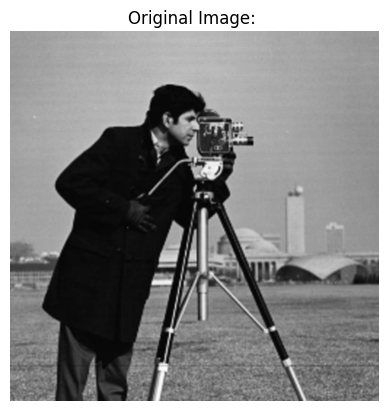

In [33]:
##print("Original Image: ")
##cv2_imshow(img)
plt.imshow(img, cmap='gray')
plt.title('Original Image: ')
plt.axis('off')
plt.show()

## Histograms
To know what the most number(color) in the image

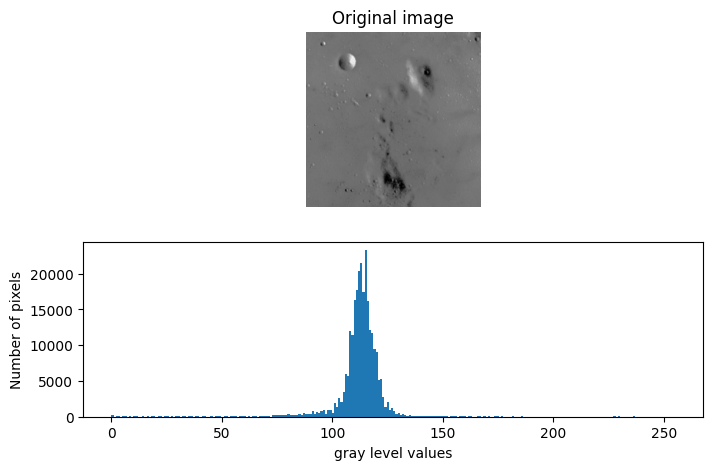

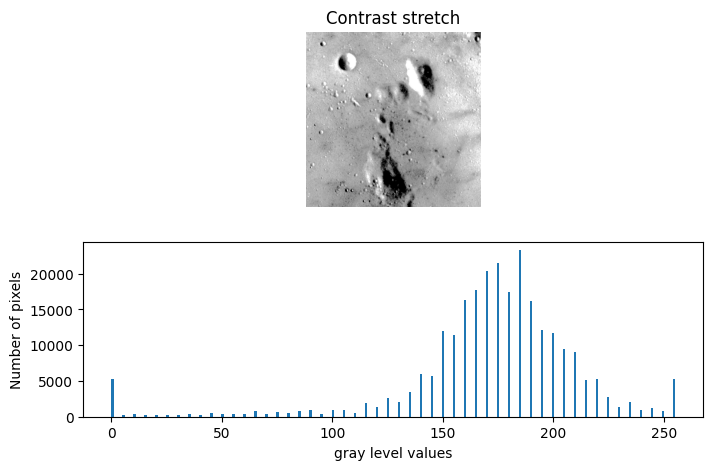

In [34]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure # brightness & contrast \\ Histogram Equalization

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98)) # only percentile
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98)) # streching

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) # first 2 args are row x coulmn and third is where to show
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

# original pic
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) # hist only recive 1D array
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

# new pic
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


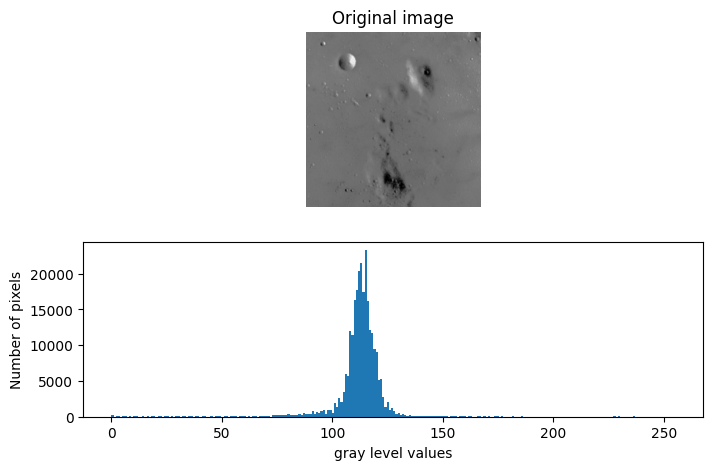

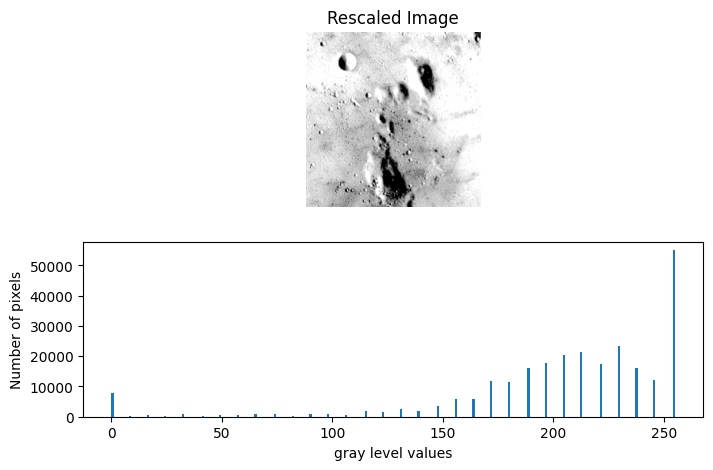

In [35]:
# Task 1 
img = data.moon()
p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

# original pic
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')


fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# new pic
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Rescaled Image')


fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

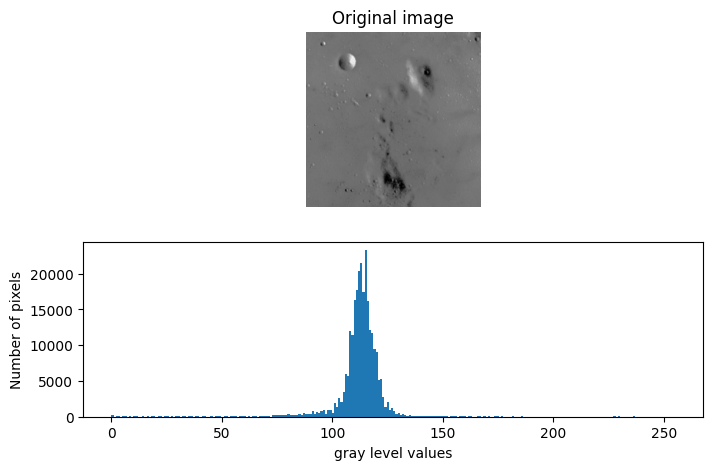

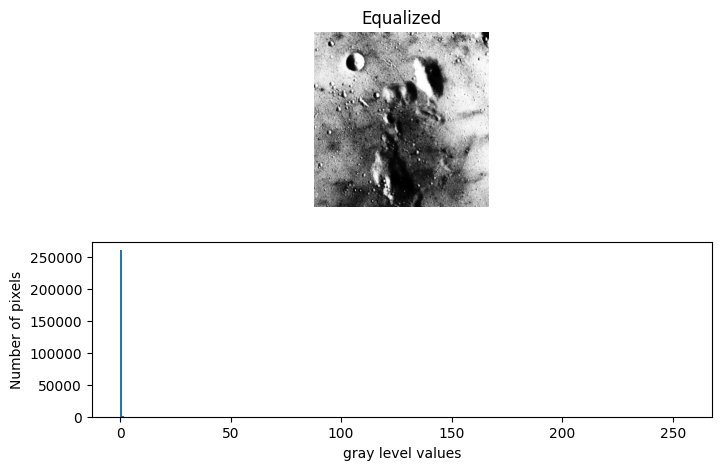

In [36]:
# Task 2 ,nbins=256, mask=None
import skimage
img_eq=skimage.exposure.equalize_hist(img)

# original pic
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')


fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# new pic
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap = 'gray')
plt.axis('off')
plt.title('Equalized')


fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


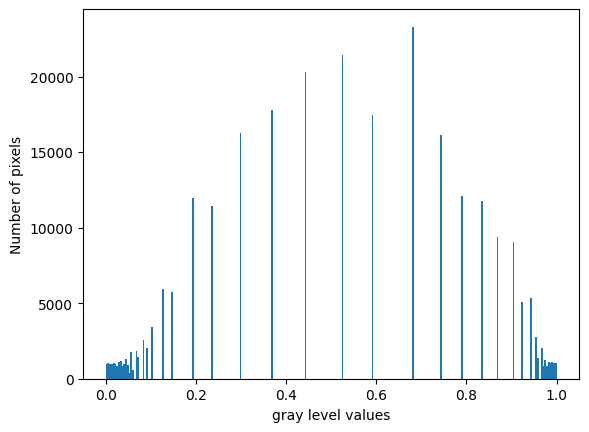

In [39]:
# skimage.exposure.equalize_hist() returning values [0,1]
plt.hist(img_eq.flat, bins = 256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

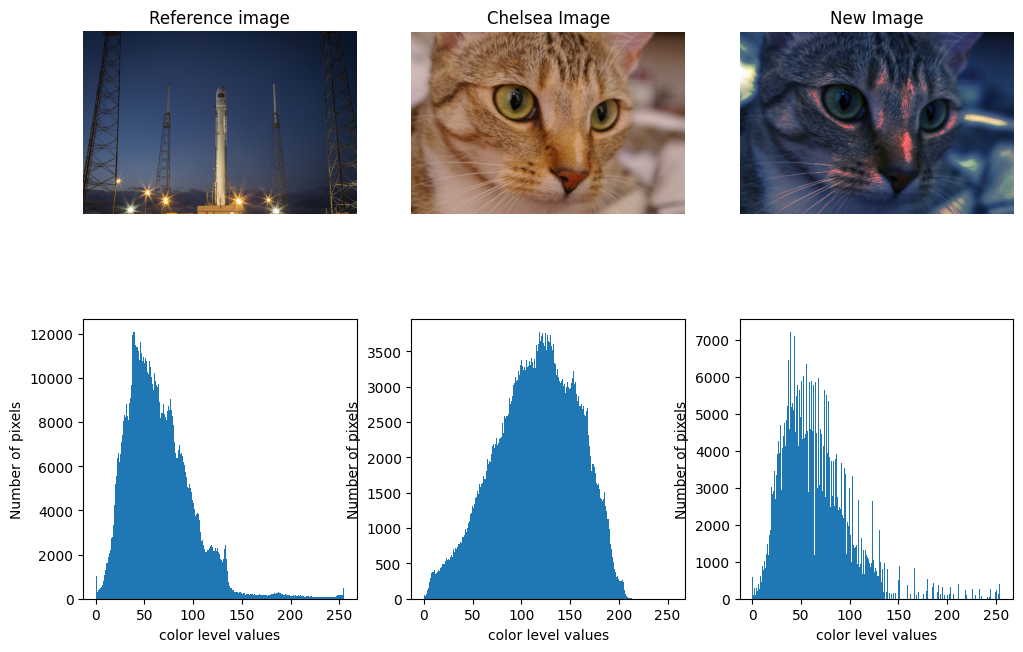

In [40]:
# Task 3

rocket = data.rocket()
chl = data.chelsea()

# channel_axis=-1 it is for the last coulmn(colors) it takes each channel
# exposure.match_histograms matches each channel 
new = exposure.match_histograms(chl, rocket, channel_axis=-1)

# reference pic
fig = plt.figure(figsize=(12, 8))
fig.add_subplot(2, 3, 1) 
plt.imshow(rocket)
plt.axis('off')
plt.title('Reference image')


fig.add_subplot(2, 3, 4)
plt.hist(rocket.flat, bins = 256, range=(0, 255)) 
plt.xlabel('color level values')
plt.ylabel('Number of pixels')

# chelsea img
fig.add_subplot(2, 3, 2)
plt.imshow(chl)
plt.axis('off')
plt.title('Chelsea Image')


fig.add_subplot(2, 3, 5)
plt.hist(chl.flat, bins = 256, range=(0, 255))
plt.xlabel('color level values')
plt.ylabel('Number of pixels')




# new img
fig.add_subplot(2, 3, 3)
plt.imshow(new)
plt.axis('off')
plt.title('New Image')


fig.add_subplot(2, 3, 6)
plt.hist(new.flat, bins = 256, range=(0, 255))
plt.xlabel('color level values')
plt.ylabel('Number of pixels')
plt.show()